# Phase 7 — Business Translation

[`walkthrough/phase7.md`](../walkthrough/phase7.md)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

DATA_PATH = "../dataset/data.csv"
df = pd.read_csv(DATA_PATH)
df["Goal_Met"] = (df["Disposable_Income"] >= df["Desired_Savings"]).astype(int)

potential_cols = [c for c in df.columns if c.startswith("Potential_Savings_")]
df["Total_Potential_Savings"] = df[potential_cols].sum(axis=1)
df["Shortfall"] = df["Desired_Savings"] - df["Disposable_Income"]

print(f"Shape: {df.shape}")

Shape: (20000, 30)


## Unrealized savings by category

In [2]:
category_totals = df[potential_cols].sum().sort_values(ascending=False)
category_means = df[potential_cols].mean().reindex(category_totals.index)
category_pct_income = (
    (df[potential_cols].div(df["Income"], axis=0)).mean().reindex(category_totals.index)
)

savings_by_category = pd.DataFrame(
    {
        "total_monthly (Rs)": category_totals.round(0),
        "mean_per_person (Rs)": category_means.round(2),
        "mean_pct_of_income": category_pct_income.round(4),
    }
)
savings_by_category.index = savings_by_category.index.str.replace(
    "Potential_Savings_", ""
)
savings_by_category

,total_monthly (Rs),mean_per_person (Rs),mean_pct_of_income
Groceries,18243944.0,912.20,0.0219
Transport,9460853.0,473.04,0.0113
Utilities,8726656.0,436.33,0.0105
Eating_Out,5099266.0,254.96,0.0061
Entertainment,5080621.0,254.03,0.0061
Miscellaneous,2898100.0,144.90,0.0035
Education,1248342.0,62.42,0.0015
Healthcare,830499.0,41.52,0.0010


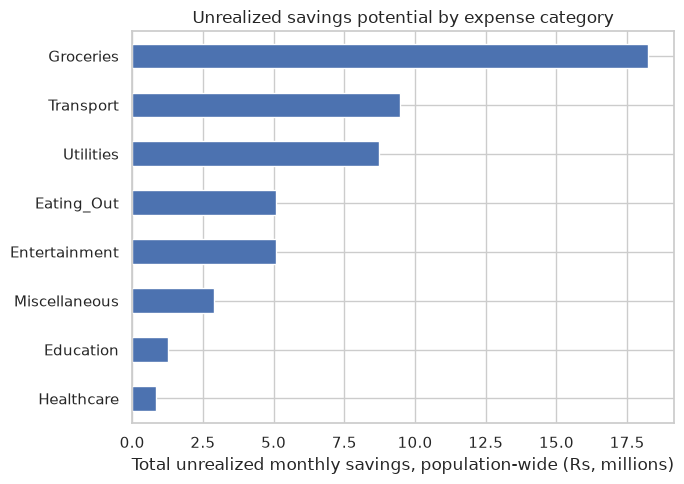

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
(savings_by_category["total_monthly (Rs)"] / 1e6).sort_values().plot(
    kind="barh", ax=ax, color="#4c72b0"
)
ax.set_xlabel("Total unrealized monthly savings, population-wide (Rs, millions)")
ax.set_title("Unrealized savings potential by expense category")
fig.tight_layout()
plt.show()

## Coverage of the at-risk shortfall

In [4]:
at_risk = df[df["Goal_Met"] == 0]

coverage = pd.Series(
    {
        "All 8 categories": (
            at_risk["Total_Potential_Savings"] >= at_risk["Shortfall"]
        ).mean(),
        "Groceries + Transport only": (
            (
                at_risk["Potential_Savings_Groceries"]
                + at_risk["Potential_Savings_Transport"]
            )
            >= at_risk["Shortfall"]
        ).mean(),
        "Groceries only": (
            at_risk["Potential_Savings_Groceries"] >= at_risk["Shortfall"]
        ).mean(),
    },
    name="share_of_at_risk_individuals_covered",
).round(4)

print(f"At-risk individuals: {len(at_risk)}")
print(
    f"Mean shortfall (Desired_Savings - Disposable_Income): Rs {at_risk['Shortfall'].mean():.2f}/month"
)
print(
    f"Mean total addressable savings potential: Rs {at_risk['Total_Potential_Savings'].mean():.2f}/month"
)
coverage.to_frame()

At-risk individuals: 112
Mean shortfall (Desired_Savings - Disposable_Income): Rs 784.04/month
Mean total addressable savings potential: Rs 2912.11/month


,share_of_at_risk_individuals_covered
All 8 categories,0.9911
Groceries + Transport only,0.8750
Groceries only,0.6339


## At-risk segment profile

In [5]:
print("At-risk individuals by City_Tier:")
print(at_risk["City_Tier"].value_counts())
print()
print("At-risk individuals by Occupation:")
print(at_risk["Occupation"].value_counts())
print()
print(
    f"Mean Dependents -- at-risk: {at_risk['Dependents'].mean():.2f}, population: {df['Dependents'].mean():.2f}"
)

At-risk individuals by City_Tier:
City_Tier
Tier_1    112
Name: count, dtype: int64

At-risk individuals by Occupation:
Occupation
Student          35
Retired          27
Self_Employed    25
Professional     25
Name: count, dtype: int64

Mean Dependents -- at-risk: 2.25, population: 2.00


## Model reliability

In [6]:
final_eval = pd.read_csv("../results/final_test_evaluation.csv", index_col=0)
final_eval.loc[["SVM (Linear) — CV-selected threshold"]]

,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
model,,,,,,,,
SVM (Linear) — CV-selected threshold,0.9992,0.88,1.0,0.9362,1.0,0.9992,0.9996,0.9679


## Recommendations

In [7]:
from pathlib import Path

recommendations = pd.DataFrame(
    [
        {
            "recommendation": "Prioritize outreach by City_Tier, not occupation or age",
            "evidence": "100% of at-risk individuals (112/112) live in Tier-1 cities; Occupation and Age show no comparable skew",
        },
        {
            "recommendation": "Lead nudge campaigns with grocery-spend reduction",
            "evidence": "Groceries is the largest unrealized-savings category: Rs 18.2M/month aggregate, ~2x the next category (Transport)",
        },
        {
            "recommendation": "Frame the ask as small and achievable, not remedial",
            "evidence": "Groceries + Transport alone closes the shortfall for 87.5% of at-risk individuals; all 8 tracked categories close it for 99.1%",
        },
        {
            "recommendation": "Deploy the SVM (Linear) classifier at threshold t=-0.4 for flagging",
            "evidence": "recall_0 = 1.0 (test set), precision_0 = 0.88 -- catches every at-risk case at the cost of ~12% unnecessary low-cost nudges",
        },
        {
            "recommendation": "Do not build a separate persona-based targeting layer",
            "evidence": "Phase 6 clustering found personas driven by City_Tier and Dependents -- signal already used by the Phase 4/5 model, not an independent source of lift",
        },
    ]
)
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)
recommendations.to_csv(results_dir / "business_recommendations.csv", index=False)
recommendations

,recommendation,evidence
0,"Prioritize outreach by City_Tier, not occupati...",100% of at-risk individuals (112/112) live in ...
1,Lead nudge campaigns with grocery-spend reduction,Groceries is the largest unrealized-savings ca...
2,"Frame the ask as small and achievable, not rem...",Groceries + Transport alone closes the shortfa...
3,Deploy the SVM (Linear) classifier at threshol...,"recall_0 = 1.0 (test set), precision_0 = 0.88 ..."
4,Do not build a separate persona-based targetin...,Phase 6 clustering found personas driven by Ci...
